# Diagnóstico de Câncer de Mama com Machine Learning

## Tech Challenge - Fase 1 | FIAP Pós Tech - AI for Devs

### Contexto do Problema

O câncer de mama é o tipo de câncer mais comum entre mulheres no mundo. A detecção precoce é fundamental para aumentar as chances de tratamento bem-sucedido. Neste notebook, vamos construir modelos de Machine Learning capazes de classificar tumores de mama como **malignos** ou **benignos** com base em características extraídas de imagens digitalizadas de aspiração por agulha fina (FNA) de massas mamárias.

### Dataset

Utilizaremos o **Wisconsin Breast Cancer Dataset**, disponível diretamente pelo scikit-learn. O dataset contém 569 amostras com 30 features numéricas extraídas de imagens de células, como raio médio, textura, perímetro, área, suavidade, entre outras.

### Objetivo

Treinar e comparar diferentes modelos de classificação para identificar qual apresenta o melhor desempenho no diagnóstico de câncer de mama, sempre lembrando que **o médico deve ter a palavra final** no diagnóstico.

---

## 1. Importação das Bibliotecas

Vamos começar importando as bibliotecas que serão utilizadas ao longo do notebook. Escolhemos ferramentas padrão do ecossistema Python para ciência de dados e ML.

In [24]:
# Bibliotecas para manipulação de dados
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [25]:
import pandas as pd
import numpy as np
import os

# Bibliotecas para visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: pré-processamento, modelos e métricas
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

# Modelos de classificação
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

# SHAP para interpretabilidade
import shap

# Importar nossas funções auxiliares
import sys
sys.path.append('..')
from src.utils import (
    plotar_distribuicao_classes, plotar_histogramas, plotar_correlacao,
    plotar_matriz_confusao, plotar_curvas_roc_comparativas,
    avaliar_modelo_cancer_mama, comparar_modelos, exibir_classification_report
)

# Configurações de visualização
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Ignorar avisos para manter o notebook limpo
import warnings
warnings.filterwarnings('ignore')

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [26]:
# Diretório para salvar os resultados (gráficos e tabelas)
DIR_RESULTADOS = os.path.join('..', 'resultados')
os.makedirs(DIR_RESULTADOS, exist_ok=True)
print(f"Gráficos serão salvos em: {os.path.abspath(DIR_RESULTADOS)}")

Gráficos serão salvos em: /home/neto/projects/fiap/ai4devs/FASE_1/tech-challenge/resultados


## 2. Carregamento e Exploração dos Dados (EDA)

Vamos carregar o dataset e entender sua estrutura. É importante conhecer bem os dados antes de qualquer modelagem — isso nos ajuda a tomar decisões melhores nas etapas seguintes.

### 2.1 Carregamento do Dataset

In [27]:
# Carregar o dataset de câncer de mama a partir do CSV
# O CSV foi gerado pelo script data/download_datasets.py
# Fonte original: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data/data

caminho_csv = os.path.join('..', 'data', 'cancer_mama.csv')

# Se o CSV ainda não existe, rodar o script de download
if not os.path.exists(caminho_csv):
    print("CSV não encontrado. Executando script de download...")
    sys.path.append(os.path.join('..', 'data'))
    from download_datasets import baixar_cancer_mama
    baixar_cancer_mama()

# Carregar o CSV
df = pd.read_csv(caminho_csv)

# Separar nomes das features (todas as colunas exceto 'diagnostico')
feature_names = [col for col in df.columns if col != 'diagnostico']

print(f"Dataset carregado de: {caminho_csv}")
print(f"Formato do dataset: {df.shape[0]} amostras e {df.shape[1]} colunas")
print(f"\nFeatures disponíveis: {feature_names}")
print(f"\nClasses: 0 = Maligno, 1 = Benigno")
df.head()

Dataset carregado de: ../data/cancer_mama.csv
Formato do dataset: 569 amostras e 32 colunas

Features disponíveis: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Classes: 0 = Maligno, 1 = Benigno


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 2.2 Informações Gerais do Dataset

Vamos verificar os tipos de dados, se há valores nulos e as estatísticas descritivas básicas.

In [28]:
# Informações gerais do DataFrame
print("=" * 60)
print("INFORMAÇÕES DO DATASET")
print("=" * 60)
df.info()

INFORMAÇÕES DO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  per

In [29]:
# Verificar valores nulos
print("Valores nulos por coluna:")
print(df.isnull().sum().to_string())
print(f"\nTotal de valores nulos no dataset: {df.isnull().sum().sum()}")

Valores nulos por coluna:
id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0

Total de valores nulos no dataset: 0


In [30]:
# Estatísticas descritivas
# Isso nos ajuda a entender a escala, a dispersão e a distribuição de cada feature
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Foi verificado que a coluna 'diagnosis' esta como object, vamos converter para numérica (0 e 1) para facilitar a modelagem.
Converter a coluna 'diagnosis' para numérica (0 = maligno, 1 = benigno)

In [31]:
df['diagnostico'] = df['diagnosis'].map({'M': 0, 'B': 1})
df.drop('diagnosis', axis=1, inplace=True)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

### 2.3 Distribuição das Classes

Uma etapa importante é verificar se as classes estão balanceadas. Se houver um desbalanceamento muito grande, os modelos podem ficar enviesados para a classe majoritária, o que seria perigoso em um contexto médico — imagine um modelo que "acerta muito" mas na verdade só classifica tudo como benigno.

  → Gráfico salvo em: ../resultados/cm_distribuicao_classes.png


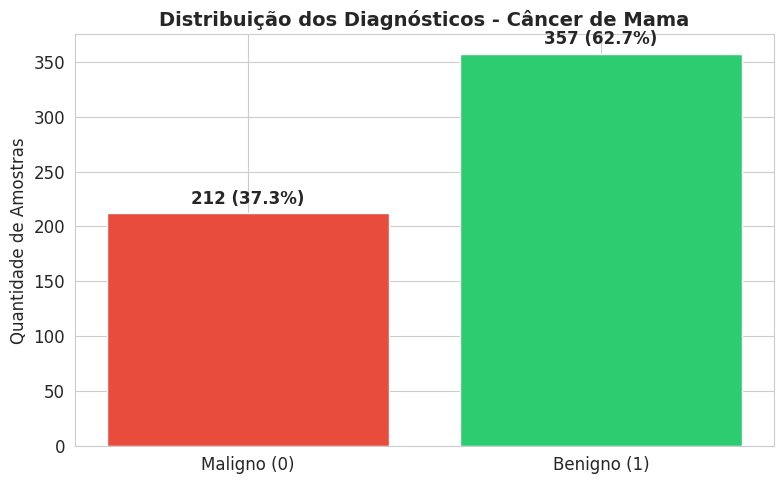

Proporção das classes:
  Maligno:  212 (37.3%)
  Benigno:  357 (62.7%)


In [33]:
# Distribuição das classes
# No dataset: 0 = maligno, 1 = benigno
plotar_distribuicao_classes(
    df['diagnostico'],
    nomes_classes=['Maligno (0)', 'Benigno (1)'],
    titulo='Distribuição dos Diagnósticos - Câncer de Mama',
    salvar_em=os.path.join(DIR_RESULTADOS, 'cm_distribuicao_classes.png')
)

# Proporção exata
print(f"Proporção das classes:")
print(f"  Maligno:  {(df['diagnostico'] == 0).sum()} ({(df['diagnostico'] == 0).mean()*100:.1f}%)")
print(f"  Benigno:  {(df['diagnostico'] == 1).sum()} ({(df['diagnostico'] == 1).mean()*100:.1f}%)")

### Análise do balanceamento das classes

O dataset apresenta uma distribuição de classes levemente desbalanceada, com aproximadamente **63% de instâncias benignas** e **37% de instâncias malignas**. Embora exista uma diferença entre as classes, esse nível de desbalanceamento não é considerado crítico.

Em termos práticos, a classe minoritária (maligna) ainda possui representatividade suficiente para que os modelos de aprendizado de máquina consigam identificar padrões relevantes sem necessidade de técnicas adicionais de balanceamento.


### Justificativa para não utilização de técnicas de balanceamento

Técnicas como o **SMOTE (Synthetic Minority Over-sampling Technique)** são geralmente recomendadas em cenários onde há desbalanceamento severo, por exemplo, quando a classe minoritária representa menos de 20% do conjunto de dados.

No presente caso, a proporção de 37% para a classe minoritária indica que:

- Há quantidade suficiente de amostras para aprendizado adequado;
- O risco de viés extremo para a classe majoritária é reduzido;
- A aplicação de técnicas de oversampling poderia introduzir **ruído artificial** e potencialmente levar ao **overfitting**, prejudicando a capacidade de generalização do modelo.

Dessa forma, optou-se por **não aplicar técnicas de balanceamento** neste momento.


### 2.4 Distribuição das Features

Nesta etapa, analisamos a distribuição das *features* (variáveis explicativas) com o objetivo de compreender melhor o comportamento dos dados e identificar possíveis padrões ou a presença de outliers.

As *features* representam as características observadas em cada registro do dataset e são utilizadas como base para a predição da variável alvo (*target*), que corresponde à informação que o modelo busca prever.

A análise da distribuição dessas variáveis permite:

- Identificar a presença de valores extremos (*outliers*), que são observações significativamente distantes do padrão geral dos dados;
- Verificar assimetrias, dispersões e possíveis inconsistências;
- Compreender melhor a relação entre as variáveis e seu impacto na predição.

Os *outliers* podem representar tanto ruídos quanto comportamentos reais do dataset, sendo importante avaliá-los com cautela antes de decidir por sua remoção ou tratamento.

Vamos fazer uma tratativa , alterando os nomes dos cabeçalhos para facilitar a visualização e interpretação dos gráficos. Por exemplo, vamos substituir "mean radius" por "Raio Médio", "mean texture" por "Textura Média", e assim por diante. Essa abordagem torna os gráficos mais acessíveis, especialmente para aqueles que não estão familiarizados com os termos técnicos em inglês.

Atenção: colunas sem tradução: {'diagnostico'}
Features de valores médios: ['raio_media', 'textura_media', 'perimetro_media', 'area_media', 'suavidade_media', 'compacidade_media', 'concavidade_media', 'pontos_concavos_media', 'simetria_media', 'dimensao_fractal_media']


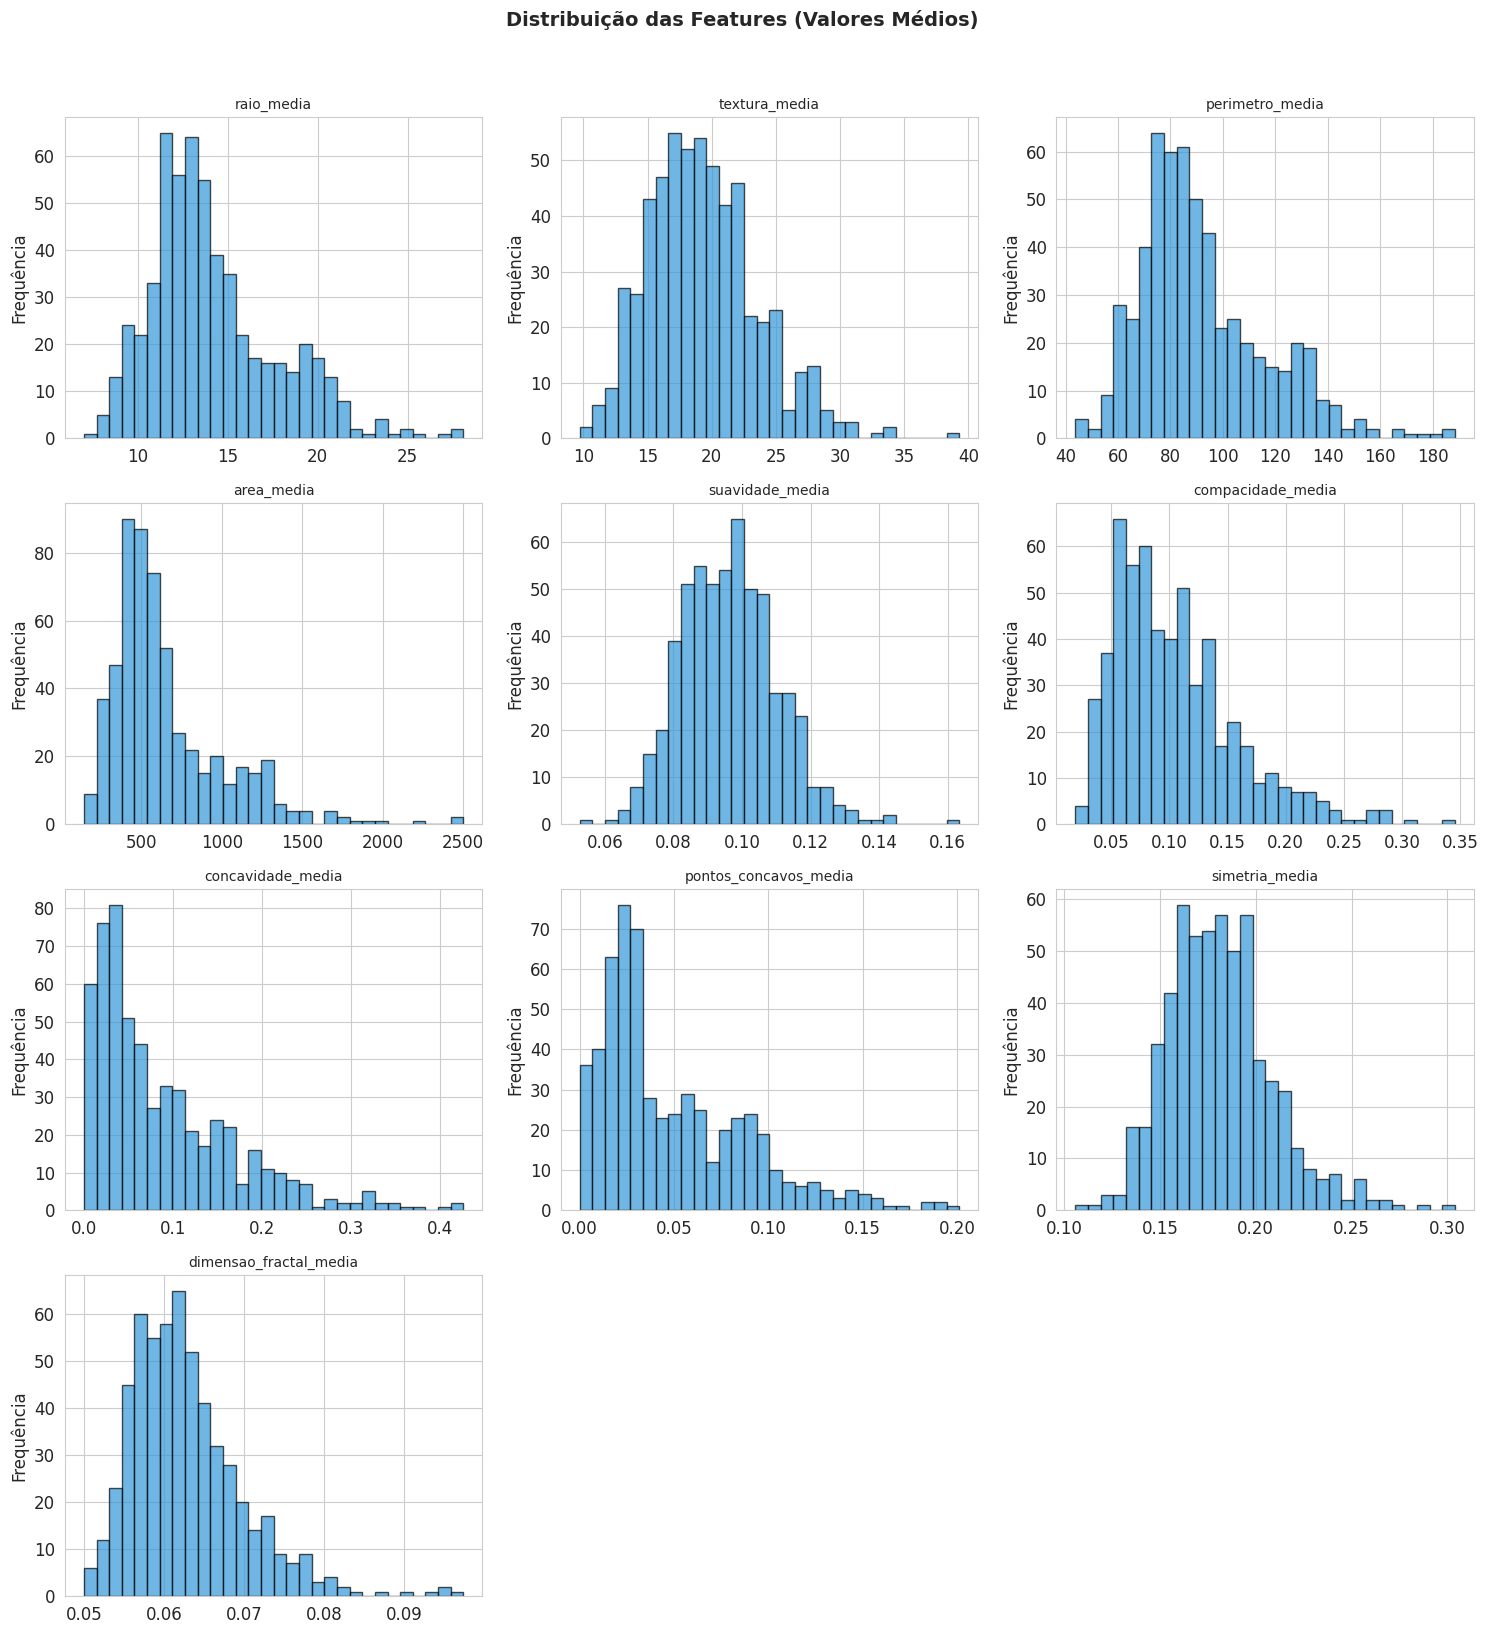

In [34]:
# Mapeamento direto: nome original -> nome traduzido
traducao_colunas = {
    'id': 'id',
    'diagnosis': 'diagnostico',

    # Valores médios (mean)
    'radius_mean': 'raio_media',
    'texture_mean': 'textura_media',
    'perimeter_mean': 'perimetro_media',
    'area_mean': 'area_media',
    'smoothness_mean': 'suavidade_media',
    'compactness_mean': 'compacidade_media',
    'concavity_mean': 'concavidade_media',
    'concave points_mean': 'pontos_concavos_media',
    'symmetry_mean': 'simetria_media',
    'fractal_dimension_mean': 'dimensao_fractal_media',

    # Erro padrão (se)
    'radius_se': 'raio_ep',
    'texture_se': 'textura_ep',
    'perimeter_se': 'perimetro_ep',
    'area_se': 'area_ep',
    'smoothness_se': 'suavidade_ep',
    'compactness_se': 'compacidade_ep',
    'concavity_se': 'concavidade_ep',
    'concave points_se': 'pontos_concavos_ep',
    'symmetry_se': 'simetria_ep',
    'fractal_dimension_se': 'dimensao_fractal_ep',

    # Pior valor (worst)
    'radius_worst': 'raio_pior',
    'texture_worst': 'textura_pior',
    'perimeter_worst': 'perimetro_pior',
    'area_worst': 'area_pior',
    'smoothness_worst': 'suavidade_pior',
    'compactness_worst': 'compacidade_pior',
    'concavity_worst': 'concavidade_pior',
    'concave points_worst': 'pontos_concavos_pior',
    'symmetry_worst': 'simetria_pior',
    'fractal_dimension_worst': 'dimensao_fractal_pior',
}

def traduzir_colunas(df, mapeamento=traducao_colunas):
    """
    Lê as colunas do DataFrame e traduz os cabeçalhos para português.
    Retorna um novo DataFrame com as colunas renomeadas.
    """
    # Verifica quais colunas do df estão no mapeamento (evita erros)
    colunas_para_traduzir = {k: v for k, v in mapeamento.items() if k in df.columns}

    # Avisa sobre colunas não mapeadas
    nao_mapeadas = set(df.columns) - set(colunas_para_traduzir.keys())
    if nao_mapeadas:
        print(f"Atenção: colunas sem tradução: {nao_mapeadas}")

    return df.rename(columns=colunas_para_traduzir)


# Aplica a tradução
df = traduzir_colunas(df)
feature_names = df.columns.tolist()

# Agora filtra as features de valores médios
features_mean = [col for col in feature_names if col.endswith('_media')]
print(f"Features de valores médios: {features_mean}")

plotar_histogramas(df, features_mean, titulo='Distribuição das Features (Valores Médios)')

### Análise dos histogramas

A partir da análise dos histogramas, observa-se que algumas features, como `raio_media`, `perimetro_media` e `area_media`, apresentam distribuições assimétricas à direita (right-skewed), com maior concentração de valores mais baixos e uma cauda estendida para valores mais altos. Esse comportamento sugere a presença de observações com valores elevados, que podem ser interpretadas como possíveis outliers ou variações relevantes nas dimensões dos tumores.

Por outro lado, variáveis como `suavidade_media` e `simetria_media` apresentam distribuições mais próximas da simetria, indicando uma dispersão mais homogênea e menor influência de valores extremos.

Entretanto, é importante destacar que essa análise é univariada e, portanto, não permite inferir diretamente a capacidade discriminativa das features em relação à variável alvo (benigno vs maligno). Para uma avaliação mais robusta, seria necessário analisar a distribuição dessas variáveis considerando a separação por classe, por meio de técnicas como boxplots condicionados ao target ou outras abordagens estatísticas.


### Questionamentos levantados

- As distribuições assimétricas observadas podem impactar o desempenho dos modelos de machine learning?
- Os valores extremos identificados representam ruído ou características relevantes do problema?
- Quais features tem mais capacidade de discriminar entre tumores benignos e malignos?
- As variáveis seguem uma distribuição normal e isso é relevante para os modelos escolhidos?
- Existe correlação ou redundância entre variáveis como `raio_media`, `perimetro_media` e `area_media`?

---

### Discussão inicial

As distribuições assimétricas podem influenciar o desempenho de alguns algoritmos, especialmente aqueles sensíveis à escala e à distribuição dos dados. Nesse sentido, transformações como normalização ou padronização podem ser consideradas.

Em relação aos valores extremos, é importante destacar que, em datasets da área da saúde, esses valores podem representar casos reais e relevantes, como tumores com dimensões maiores. Portanto, a remoção de outliers deve ser realizada com cautela, após análise mais aprofundada.

Além disso, a análise univariada realizada até o momento não permite avaliar diretamente o poder discriminativo das variáveis. Para isso, será necessário considerar a relação das features com a variável alvo, por meio de análises adicionais, como visualizações por classe e métricas estatísticas.

Por fim, considerando a possível relação entre algumas variáveis (como raio, perímetro e área), torna-se relevante investigar a existência de correlação entre elas, uma vez que isso pode impactar modelos sensíveis à multicolinearidade.

---

### Próximos passos

Com base nos questionamentos levantados, as próximas etapas da análise incluirão:

- Avaliação da distribuição das variáveis por classe (benigno vs maligno);
- Análise de correlação entre as features;
- Identificação do impacto de outliers no desempenho dos modelos;
- Aplicação de técnicas de pré-processamento, quando necessário;
- Avaliação do poder discriminativo das variáveis.

Essas etapas são fundamentais para garantir uma modelagem mais robusta e bem fundamentada.

Boxplots para comparação entre classes (maligno vs. benigno)

Para analisar as diferenças entre tumores malignos e benignos, utilizamos boxplots de algumas features consideradas relevantes. Essas variáveis foram escolhidas por representarem aspectos importantes como tamanho, forma e textura dos tumores.

1. Representatividade geométrica do tumor
raio_media, perimetro_media, area_media
Essas variáveis estão diretamente relacionadas ao tamanho e à escala do tumor. Em geral, tumores malignos tendem a apresentar maiores dimensões ou crescimento mais irregular, tornando essas features altamente informativas para a diferenciação entre classes.

2. Textura e heterogeneidade
textura_media
Essa feature captura variações na intensidade dos pixels nas imagens médicas, refletindo a heterogeneidade do tecido. Tumores malignos costumam apresentar texturas mais irregulares.

3. Regularidade da borda
suavidade_media
Indica o grau de suavidade ou irregularidade do contorno do tumor. Tumores malignos geralmente possuem bordas menos regulares.

4. Formato e compactação
compacidade_media
Relaciona área e perímetro para medir o quão compacto é o tumor. Tumores benignos tendem a apresentar formas mais regulares e compactas, enquanto tumores malignos costumam ser mais irregulares e dispersos.

  → Gráfico salvo em: ../resultados/cm_boxplots.png


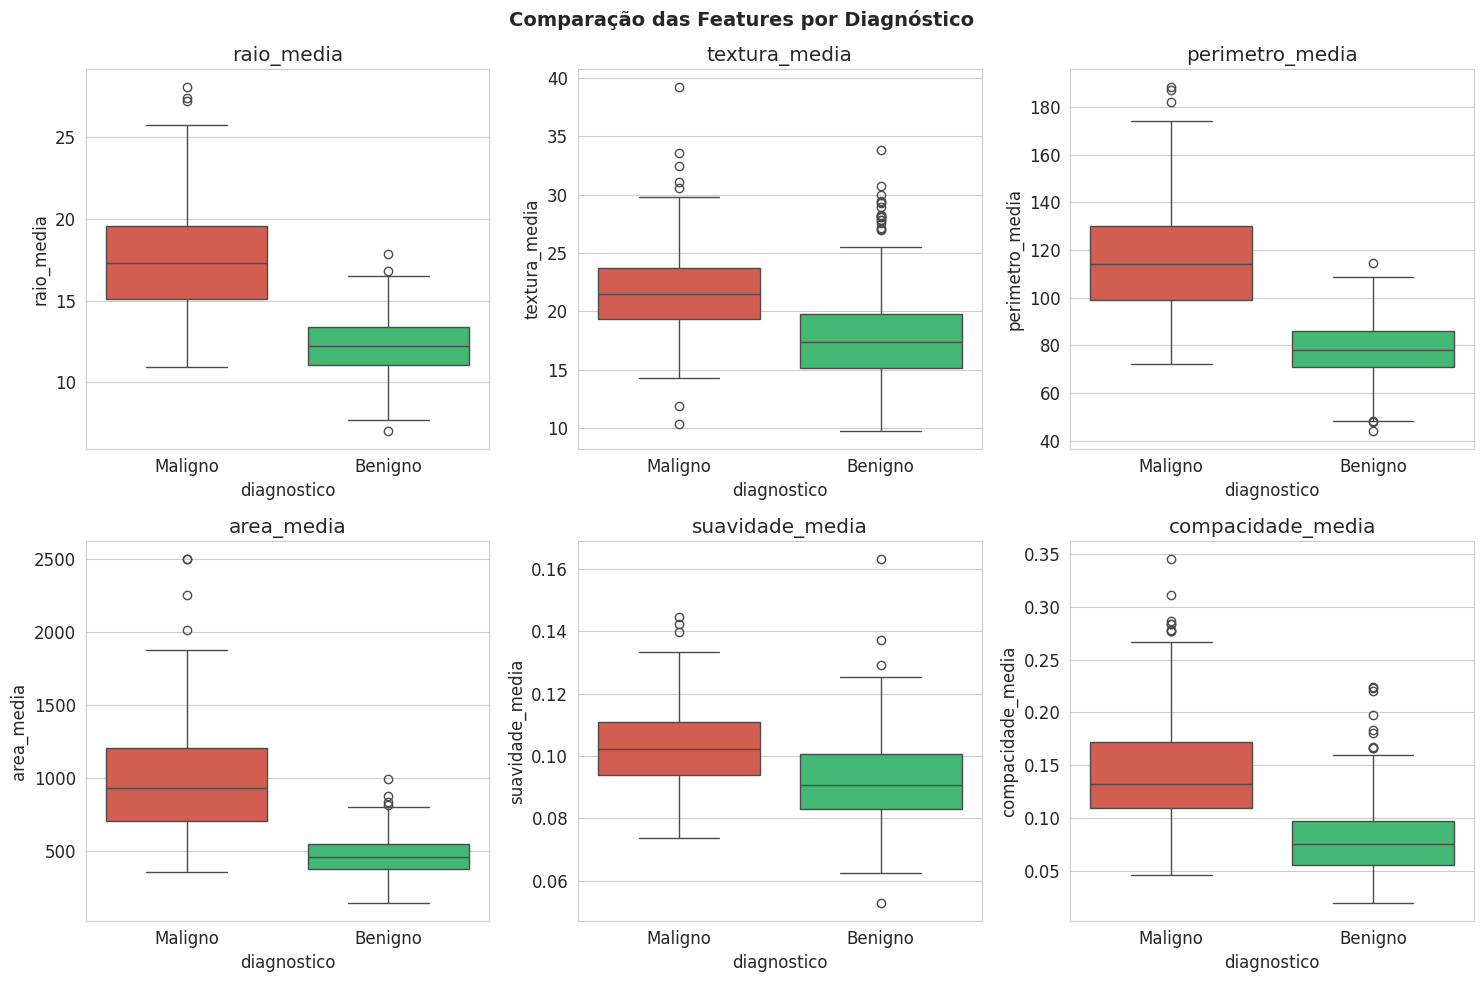

In [35]:
features_destaque = ['raio_media', 'textura_media', 'perimetro_media', 'area_media',
                     'suavidade_media', 'compacidade_media']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(features_destaque):
    sns.boxplot(data=df, x='diagnostico', y=feature, ax=axes[i],
                palette=['#e74c3c', '#2ecc71'])
    axes[i].set_xticklabels(['Maligno', 'Benigno'])
    axes[i].set_title(feature)

fig.suptitle('Comparação das Features por Diagnóstico', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(DIR_RESULTADOS, 'cm_boxplots.png'), dpi=150, bbox_inches='tight')
print(f"  → Gráfico salvo em: {os.path.join(DIR_RESULTADOS, 'cm_boxplots.png')}")
plt.show()

Análise dos boxplots

Observa-se que features como raio_medio, perimetro_medio e area_media apresentam uma separação bastante clara entre tumores malignos e benignos. Em geral, tumores malignos tendem a possuir valores mais elevados nessas medidas, o que é consistente do ponto de vista biológico, já que costumam crescer mais e de forma menos controlada.

Por outro lado, a feature suavidade_media apresenta menor capacidade de separação entre as classes, indicando que pode ter um poder discriminativo mais limitado para a tarefa de classificação.

3. Pré-processamento dos Dados

Antes do treinamento dos modelos, é fundamental preparar os dados adequadamente. Essa etapa garante melhor desempenho e maior confiabilidade nos resultados. O pré-processamento inclui:

Separação entre variáveis preditoras (features) e variável alvo
Análise de correlação entre as features
Aplicação de escalonamento (feature scaling)
Divisão dos dados em conjuntos de treino e teste
3.1 Análise de Correlação

Nesta etapa, analisamos a correlação entre as features para identificar possíveis relações fortes entre elas. Variáveis altamente correlacionadas podem introduzir redundância no modelo, especialmente em algoritmos mais sensíveis a esse aspecto.

Ainda assim, neste primeiro momento, optamos por manter todas as features e observar como os modelos se comportam antes de aplicar qualquer técnica de redução de dimensionalidade.

  → Gráfico salvo em: ../resultados/cm_correlacao.png


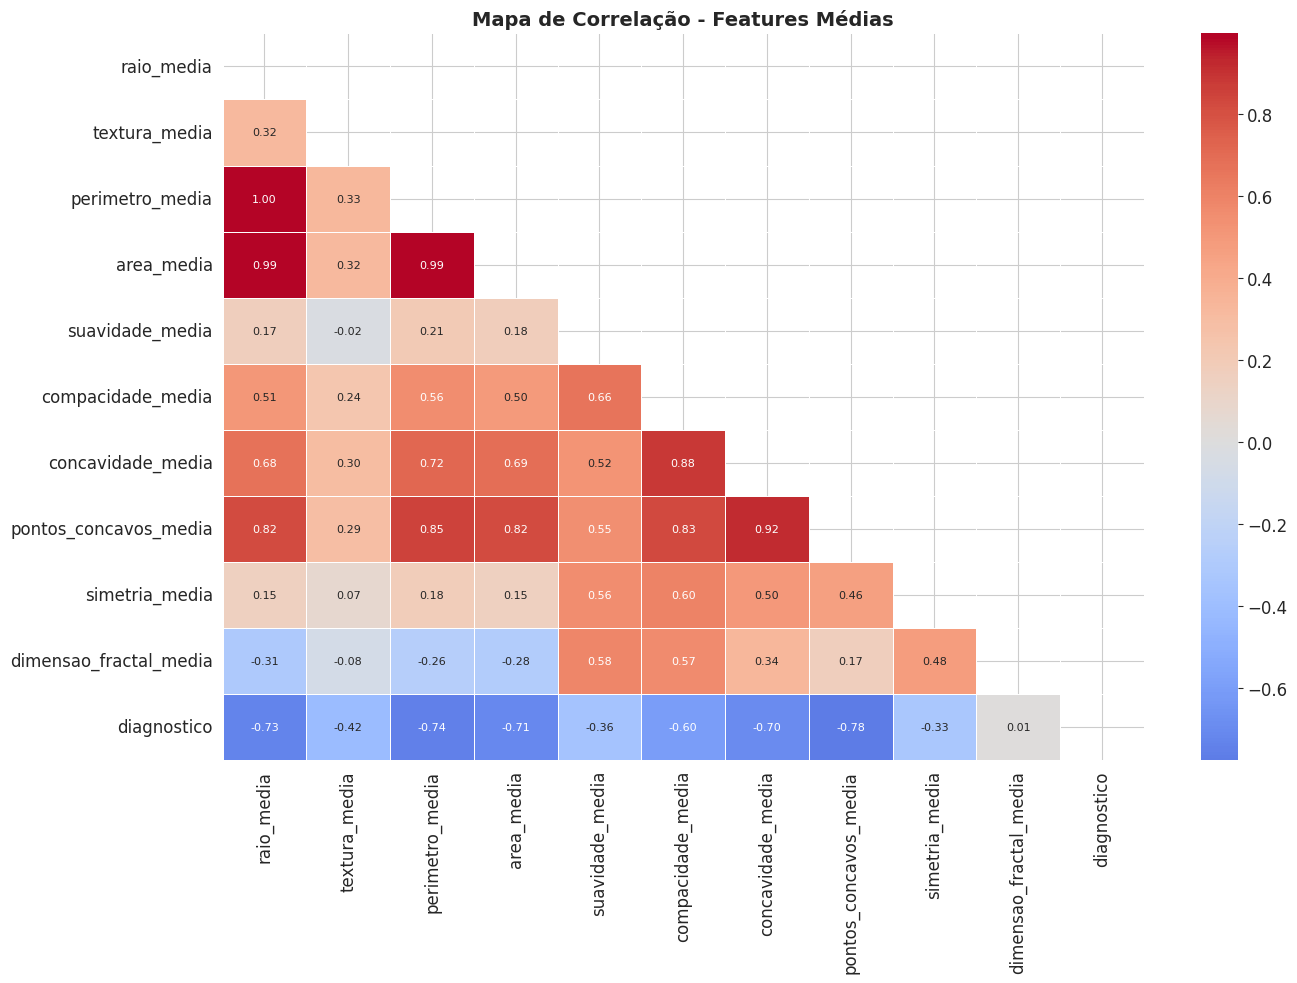

In [36]:
# Análise de correlação - vamos usar apenas as features 'mean' para o heatmap ficar legível
df_mean = df[features_mean + ['diagnostico']]
correlacao = plotar_correlacao(df_mean, titulo='Mapa de Correlação - Features Médias',
                        salvar_em=os.path.join(DIR_RESULTADOS, 'cm_correlacao.png'))

1. Mapa de correlação

O mapa de correlação foi apresentado utilizando apenas metade da matriz (triângulo inferior), o que é uma prática comum em análise exploratória de dados.

Isso ocorre porque a matriz de correlação é simétrica, ou seja, a correlação entre duas variáveis é igual independentemente da ordem (por exemplo, a correlação entre raio_medio e area_media é a mesma que entre area_media e raio_medio).

Dessa forma, exibir a matriz completa resultaria em informação duplicada.

Ao mostrar apenas metade da matriz, evitamos redundância e reduzimos a poluição visual, tornando a interpretação mais clara e objetiva.

Além disso, a diagonal principal apresenta valor igual a 1, pois representa a correlação de cada variável com ela mesma.

2. Interpretação do mapa de correlação

Observa-se uma alta correlação entre variáveis geométricas, como raio_medio, perimetro_medio e area_media, já que todas estão diretamente relacionadas ao tamanho do tumor. Isso indica possível redundância entre essas variáveis.

Além disso, features como concavidade_media e pontos_concavos_media também apresentam forte correlação entre si, sugerindo que descrevem aspectos semelhantes da forma do tumor.

Em relação à variável alvo diagnostico, nota-se uma correlação negativa relevante com várias features, especialmente aquelas ligadas ao tamanho e irregularidade. Isso indica que valores mais altos nessas variáveis estão associados a tumores malignos.

Apesar dessas correlações, optamos inicialmente por manter todas as variáveis e avaliar o impacto nos modelos antes de aplicar técnicas de redução de dimensionalidade.

<!-- PARAMOS AQUI -->

In [37]:
# Identificar pares de features com alta correlação (acima de 0.9)
# Isso nos ajuda a entender a redundância nos dados
correlacao_completa = df.drop('diagnostico', axis=1).corr()
pares_alta_corr = []

for i in range(len(correlacao_completa.columns)):
    for j in range(i + 1, len(correlacao_completa.columns)):
        if abs(correlacao_completa.iloc[i, j]) > 0.9:
            pares_alta_corr.append({
                'Feature 1': correlacao_completa.columns[i],
                'Feature 2': correlacao_completa.columns[j],
                'Correlação': correlacao_completa.iloc[i, j]
            })

df_corr = pd.DataFrame(pares_alta_corr).sort_values('Correlação', ascending=False)
print(f"Pares de features com correlação acima de 0.9: {len(df_corr)}")
df_corr

Pares de features com correlação acima de 0.9: 21


,Feature 1,Feature 2,Correlação
0,raio_media,perimetro_media,0.997855
18,raio_pior,perimetro_pior,0.993708
1,raio_media,area_media,0.987357
6,perimetro_media,area_media,0.986507
19,raio_pior,area_pior,0.984015
20,perimetro_pior,area_pior,0.977578
15,raio_ep,perimetro_ep,0.972794
8,perimetro_media,perimetro_pior,0.970387
2,raio_media,raio_pior,0.969539
7,perimetro_media,raio_pior,0.969476


**Análise da correlação:** Existem vários pares de features altamente correlacionadas, como `raio_media`, `perimetro-media` e `area_media` — o que faz sentido, pois raio, perímetro e área de um círculo são matematicamente relacionados. Essa redundância não impede os modelos de funcionar, mas é algo a se considerar em trabalhos futuros (por exemplo, usando PCA para redução de dimensionalidade).

### 3.2 Separação dos Dados e Feature Scaling

Agora vamos separar as features (X) da variável alvo (y), dividir em treino e teste, e aplicar escalonamento.

**Por que escalonar os dados?** Algoritmos como KNN e Regressão Logística são sensíveis à escala das features. Se uma feature varia de 0 a 1 e outra de 0 a 1000, a segunda vai dominar o cálculo de distância. Vamos testar dois escaladores para ver qual funciona melhor:
- **StandardScaler**: transforma os dados para média 0 e desvio padrão 1
- **MinMaxScaler**: transforma os dados para o intervalo [0, 1]

In [38]:
# Separar features (X) e variável alvo (y)
X = df.drop('diagnostico', axis=1)
y = df['diagnostico']

# Dividir em treino e teste (80/20)
# Usamos stratify=y para manter a proporção das classes em ambos os conjuntos
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Conjunto de treino: {X_treino.shape[0]} amostras")
print(f"Conjunto de teste:  {X_teste.shape[0]} amostras")
print(f"\nProporção das classes no treino:")
print(f"  Maligno: {(y_treino == 0).sum()} ({(y_treino == 0).mean()*100:.1f}%)")
print(f"  Benigno: {(y_treino == 1).sum()} ({(y_treino == 1).mean()*100:.1f}%)")
print(f"\nProporção das classes no teste:")
print(f"  Maligno: {(y_teste == 0).sum()} ({(y_teste == 0).mean()*100:.1f}%)")
print(f"  Benigno: {(y_teste == 1).sum()} ({(y_teste == 1).mean()*100:.1f}%)")

Conjunto de treino: 455 amostras
Conjunto de teste:  114 amostras

Proporção das classes no treino:
  Maligno: 170 (37.4%)
  Benigno: 285 (62.6%)

Proporção das classes no teste:
  Maligno: 42 (36.8%)
  Benigno: 72 (63.2%)


### 3.2 Separação dos Dados e Feature Scaling (continuação)

Depois de separar as variáveis de entrada (X) e a variável alvo (y), o próximo passo foi dividir os dados em treino e teste. Essa etapa é importante para verificar se o modelo realmente consegue generalizar ou se ele apenas decorou os dados utilizados no treinamento.

Foi utilizada a função `train_test_split`, com 80% dos dados para treino e 20% para teste. Também foi aplicado o parâmetro `stratify=y`, que mantém a mesma proporção de casos benignos e malignos nos dois conjuntos. Isso é especialmente importante em problemas da área da saúde, onde a distribuição das classes pode influenciar diretamente na avaliação do modelo.

Ao analisar a divisão dos dados, é possível observar que essa proporção foi preservada tanto no treino quanto no teste, o que ajuda a evitar resultados distorcidos.

---

Outro ponto importante nessa etapa foi o escalonamento dos dados (feature scaling). Isso foi necessário porque as variáveis do dataset possuem escalas diferentes. Algumas apresentam valores pequenos, enquanto outras possuem valores bem maiores.

Se esse problema não for tratado, alguns algoritmos podem acabar dando mais peso para variáveis com valores maiores, o que pode prejudicar o aprendizado do modelo. Isso acontece principalmente em algoritmos como KNN e Regressão Logística.

Para resolver isso, foi utilizado o `StandardScaler`, que padroniza os dados para que todas as variáveis tenham média 0 e desvio padrão 1. Dessa forma, todas passam a ter a mesma escala, evitando que alguma variável tenha influência desproporcional.

Outro cuidado importante foi aplicar o `fit_transform` apenas nos dados de treino e depois utilizar apenas o `transform` nos dados de teste. Isso evita o vazamento de dados (data leakage), garantindo que o modelo não tenha acesso a informações do conjunto de teste durante o treinamento.

---

De forma geral, essa etapa foi importante para:

- Separar corretamente os dados de entrada e saída;
- Garantir uma avaliação mais realista do modelo;
- Padronizar as variáveis para melhorar o desempenho dos algoritmos.

Esses cuidados ajudam a tornar o modelo mais confiável, principalmente considerando que estamos lidando com dados da área da saúde.

---

### Questionamentos sobre a separação dos dados e escalonamento

Durante essa etapa, alguns pontos importantes foram levantados.

Um dos principais questionamentos foi em relação à divisão entre treino e teste. Será que a proporção de 80/20 é a mais adequada? Em alguns casos, utilizar mais dados para treino pode melhorar o aprendizado do modelo, mas ao mesmo tempo reduz a quantidade de dados disponíveis para avaliação.

Outro ponto foi o uso do parâmetro `stratify`. Caso ele não fosse utilizado, poderia ocorrer um desbalanceamento entre as classes nos conjuntos de treino e teste, o que impactaria diretamente na avaliação do modelo. Isso é ainda mais crítico em problemas da área da saúde.

Também foi levantada a questão sobre a necessidade do escalonamento dos dados. Nem todos os algoritmos são sensíveis à escala, como é o caso de árvores de decisão. Isso levanta a dúvida se essa etapa é sempre necessária ou se depende do modelo utilizado.

Outro questionamento importante foi sobre o risco de vazamento de dados (data leakage). Caso o escalonamento fosse aplicado antes da separação entre treino e teste, o modelo poderia acabar utilizando informações do conjunto de teste, gerando resultados irreais.

Além disso, surge a dúvida sobre qual técnica de escalonamento seria mais adequada, como StandardScaler ou MinMaxScaler. Cada uma possui características diferentes, e essa escolha pode impactar o desempenho dependendo do modelo.

Por fim, considerando que estamos lidando com dados médicos, é válido questionar se essa divisão dos dados representa bem um cenário real. Em ambientes hospitalares, os dados podem mudar ao longo do tempo, o que pode exigir estratégias mais robustas de validação.

---

Esses questionamentos mostram que a construção de um modelo de Machine Learning não envolve apenas a implementação, mas também a análise crítica das decisões tomadas ao longo do processo.

### 3.3 Comparação de Escaladores: StandardScaler vs MinMaxScaler

Antes de definir qual escalador usar, vamos testar ambos com um modelo simples (Regressão Logística) para ver qual produz melhores resultados. Essa é uma boa prática: ao invés de escolher arbitrariamente, deixamos os dados nos mostrarem qual funciona melhor.

In [39]:
# Comparar StandardScaler vs MinMaxScaler usando validação cruzada
# Usamos Pipeline para garantir que o escalonamento é feito corretamente
# (ajustado no treino, aplicado no teste — evita data leakage)

# Pipeline com StandardScaler
pipeline_standard = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LogisticRegression(max_iter=10000, random_state=42))
])

# Pipeline com MinMaxScaler
pipeline_minmax = Pipeline([
    ('scaler', MinMaxScaler()),
    ('modelo', LogisticRegression(max_iter=10000, random_state=42))
])

# Validação cruzada com 5 folds
scores_standard = cross_val_score(pipeline_standard, X_treino, y_treino, cv=5, scoring='f1_weighted')
scores_minmax = cross_val_score(pipeline_minmax, X_treino, y_treino, cv=5, scoring='f1_weighted')

print("Comparação dos Escaladores (F1-Score com Validação Cruzada - 5 folds)")
print("=" * 65)
print(f"StandardScaler: {scores_standard.mean():.4f} (+/- {scores_standard.std():.4f})")
print(f"MinMaxScaler:   {scores_minmax.mean():.4f} (+/- {scores_minmax.std():.4f})")

if scores_standard.mean() > scores_minmax.mean():
    print(f"\n→ StandardScaler apresentou resultado ligeiramente melhor. Vamos usá-lo.")
    scaler_escolhido = StandardScaler()
    nome_scaler = "StandardScaler"
else:
    print(f"\n→ MinMaxScaler apresentou resultado ligeiramente melhor. Vamos usá-lo.")
    scaler_escolhido = MinMaxScaler()
    nome_scaler = "MinMaxScaler"

Comparação dos Escaladores (F1-Score com Validação Cruzada - 5 folds)
StandardScaler: 0.9801 (+/- 0.0129)
MinMaxScaler:   0.9711 (+/- 0.0194)

→ StandardScaler apresentou resultado ligeiramente melhor. Vamos usá-lo.


### 3.3 Comparação de Escaladores: StandardScaler vs MinMaxScaler

Antes de definir qual técnica de escalonamento seria utilizada no restante do projeto, foi feita uma comparação entre o StandardScaler e o MinMaxScaler. A ideia foi testar na prática qual deles se adapta melhor aos dados, em vez de simplesmente escolher um sem validação.

Para essa comparação, foi utilizado um modelo de Regressão Logística, pois esse tipo de algoritmo é sensível à escala das variáveis. Assim, fica mais fácil perceber como cada técnica de normalização impacta no desempenho do modelo.

Também foi utilizado o conceito de pipeline, que permite aplicar o escalonamento junto com o modelo de forma organizada. Isso garante que o processo aconteça corretamente dentro do treinamento, evitando problemas como o vazamento de dados.

Além disso, a avaliação foi feita utilizando validação cruzada com 5 folds. Isso significa que o modelo foi treinado e testado várias vezes com diferentes divisões dos dados, tornando a análise mais confiável do que usar apenas uma separação simples entre treino e teste.

Com base nos resultados obtidos, o StandardScaler apresentou um desempenho ligeiramente superior ao MinMaxScaler. Mesmo que a diferença não tenha sido muito grande, foi escolhido o StandardScaler para as próximas etapas do projeto.

---

Essa etapa foi importante porque mostrou que pequenas decisões, como a escolha do método de escalonamento, podem influenciar o desempenho do modelo. Por isso, em vez de assumir uma escolha, foi feita uma comparação prática entre as opções.

---

### Por que utilizar validação cruzada?

Durante essa comparação, foi utilizada a validação cruzada para tornar a avaliação mais confiável. Em vez de dividir os dados apenas uma vez, esse método separa o conjunto em várias partes e realiza múltiplos treinos e testes.

A principal vantagem disso é reduzir a dependência de uma única divisão dos dados. Quando usamos apenas um split, o resultado pode variar bastante dependendo de como os dados foram separados. Já com a validação cruzada, o modelo é testado em diferentes cenários.

Neste projeto, foi utilizada validação cruzada com 5 folds. Ou seja, os dados foram divididos em 5 partes, e o modelo foi treinado e avaliado 5 vezes, utilizando combinações diferentes de treino e validação.

Essa abordagem é especialmente útil em datasets menores, pois permite aproveitar melhor os dados disponíveis.

---

De forma geral, a validação cruzada ajuda a obter uma estimativa mais realista do desempenho do modelo, deixando a escolha das técnicas mais confiável.

---

### Questionamentos sobre a comparação de escaladores e uso de pipeline

Durante essa etapa, alguns pontos importantes foram levantados.

Um dos primeiros questionamentos foi sobre a escolha da Regressão Logística como modelo base. Apesar de ser sensível à escala, surge a dúvida se o resultado seria o mesmo com algoritmos menos dependentes disso, como árvores de decisão.

Também foi questionado se a comparação entre escalonadores sempre traz ganhos relevantes, já que em alguns casos a diferença de desempenho pode ser pequena.

Outro ponto foi o uso do pipeline. Ele ajuda a organizar o processo e evita vazamento de dados, mas levanta a reflexão sobre o que poderia acontecer caso o escalonamento fosse feito fora desse fluxo.

Além disso, foi considerado se o uso de 5 folds na validação cruzada é suficiente ou se seria interessante testar com mais divisões, mesmo com aumento do custo computacional.

Também surge a dúvida sobre a escolha da métrica de avaliação, principalmente por se tratar de um problema da área da saúde, onde diferentes tipos de erro podem ter impactos distintos.

Por fim, considerando que a diferença entre os escalonadores foi pequena, fica a reflexão se essa escolha terá um impacto relevante nas próximas etapas ou se outros fatores terão maior influência no desempenho final.

---

Esses questionamentos mostram que o desenvolvimento do modelo não envolve apenas a implementação, mas também a análise crítica das decisões tomadas ao longo do processo.

In [40]:
# Aplicar o escalador escolhido nos dados
scaler = scaler_escolhido
X_treino_scaled = scaler.fit_transform(X_treino)
X_teste_scaled = scaler.transform(X_teste)  # Apenas transform, sem fit!

print(f"Escalador utilizado: {nome_scaler}")
print(f"Shape dos dados de treino escalonados: {X_treino_scaled.shape}")
print(f"Shape dos dados de teste escalonados: {X_teste_scaled.shape}")

Escalador utilizado: StandardScaler
Shape dos dados de treino escalonados: (455, 31)
Shape dos dados de teste escalonados: (114, 31)


### Aplicação do escalonamento nos dados

Após definir o melhor método de escalonamento, o próximo passo foi aplicá-lo aos dados de treino e teste. Para isso, foi utilizado o scaler escolhido (neste caso, o StandardScaler).

O método `fit_transform` foi aplicado nos dados de treino (`X_treino`). Isso significa que o scaler foi ajustado com base nesses dados, aprendendo parâmetros como média e desvio padrão, e em seguida transformando os dados.

Já nos dados de teste (`X_teste`), foi utilizado apenas o método `transform`. Isso é importante porque garante que os dados de teste sejam transformados utilizando os mesmos parâmetros aprendidos no treino, sem que o modelo tenha acesso a informações desse conjunto durante o processo de ajuste.

Esse cuidado é fundamental para evitar o chamado vazamento de dados (data leakage), que pode fazer com que o modelo apresente resultados melhores do que realmente teria em um cenário real.

Além disso, foi feita a verificação do shape dos dados após o escalonamento, confirmando que a quantidade de amostras e features foi mantida, apenas com alteração na escala dos valores.

---

De forma geral, essa etapa garante que os dados estejam preparados corretamente para o treinamento dos modelos, mantendo a consistência entre treino e teste.

---

### Questionamentos sobre a aplicação do escalonamento

Durante essa etapa, alguns questionamentos importantes podem ser levantados.

Um dos principais pontos é sobre o uso do `fit_transform` apenas nos dados de treino. O que aconteceria se o `fit` também fosse aplicado nos dados de teste? Nesse caso, o modelo teria acesso indireto a informações do conjunto de teste, comprometendo a avaliação.

Outro questionamento é se o escalonamento sempre traz benefícios. Como visto anteriormente, alguns algoritmos não são sensíveis à escala, o que levanta a dúvida se essa etapa é sempre necessária ou depende do modelo utilizado.

Também é possível questionar se o mesmo tipo de escalonamento escolhido continuará sendo o melhor nas próximas etapas, principalmente ao utilizar modelos diferentes.

Além disso, surge a reflexão sobre a consistência dos dados. Em um cenário real, novos dados podem ter distribuições diferentes, o que pode impactar o desempenho do modelo ao aplicar o mesmo scaler treinado anteriormente.

Por fim, é importante considerar se apenas o escalonamento é suficiente para preparar os dados, ou se outras técnicas de pré-processamento poderiam melhorar ainda mais os resultados.

---

Esses questionamentos mostram que, mesmo em etapas aparentemente simples, existem decisões importantes que podem impactar diretamente o desempenho e a confiabilidade do modelo.

---

## 4. Modelagem

Agora vamos treinar três modelos de classificação diferentes. A ideia é comparar abordagens distintas para entender qual se adapta melhor ao nosso problema:

1. **Regressão Logística** — modelo linear simples e interpretável, bom como baseline. Apesar do nome "regressão", é usado para classificação. Funciona bem quando as classes são linearmente separáveis.

2. **KNN (K-Nearest Neighbors)** — classifica com base na "vizinhança" de cada amostra. A ideia é simples: se os vizinhos mais próximos de um ponto são malignos, ele provavelmente é maligno. É sensível à escala dos dados (por isso o escalonamento é importante).

3. **Árvore de Decisão** — cria regras de decisão do tipo "se feature X > valor, então...". É muito interpretável e nos permite entender quais features o modelo considera mais importantes.

### 4.1 Modelo 1: Regressão Logística

O primeiro modelo utilizado foi a Regressão Logística. Ela foi escolhida como modelo inicial (baseline) por ser simples, rápida de treinar e fácil de interpretar.

Apesar do nome, a Regressão Logística é utilizada para problemas de classificação. Ela funciona estimando a probabilidade de uma amostra pertencer a uma determinada classe, com base em uma combinação linear das variáveis de entrada.

Uma das vantagens desse modelo é que ele permite entender melhor a relação entre as variáveis e o resultado, além de servir como um bom ponto de partida para comparação com modelos mais complexos.

Além disso, como já foi visto anteriormente, a Regressão Logística é sensível à escala dos dados, o que reforça a importância da etapa de normalização realizada antes do treinamento.

---

Após o treinamento do modelo com os dados de treino, foram feitas previsões utilizando o conjunto de teste, que não foi visto durante o treinamento. Isso permite avaliar de forma mais realista o desempenho do modelo.

Também foi utilizada a função `predict_proba`, que retorna a probabilidade de cada amostra pertencer a cada classe. Isso pode ser útil em cenários reais, onde não basta apenas classificar, mas também entender o nível de confiança da previsão.

---

A avaliação do modelo foi feita utilizando o classification report, que apresenta métricas como precisão (precision), recall e f1-score para cada classe.

Analisando os resultados, é possível observar que o modelo apresentou um bom desempenho geral, com valores altos nas métricas avaliadas. Isso indica que o modelo conseguiu identificar corretamente a maioria dos casos, tanto benignos quanto malignos.

---

### Questionamentos sobre o uso da Regressão Logística

Durante essa etapa, alguns pontos importantes podem ser levantados.

Um dos principais questionamentos é se a Regressão Logística é suficiente para capturar a complexidade do problema. Como se trata de um modelo linear, pode ter dificuldades em lidar com relações mais complexas entre as variáveis.

Também surge a dúvida sobre o impacto das features utilizadas. Será que todas as variáveis contribuem igualmente para o modelo, ou algumas poderiam ser removidas sem prejudicar o desempenho?

Outro ponto relevante é a interpretação das métricas. Mesmo com bons resultados, é importante analisar se o modelo está cometendo erros críticos, principalmente em casos de tumores malignos, onde um erro pode ter consequências mais graves.

Além disso, é possível questionar se o modelo estaria sofrendo overfitting, ou seja, se ele aprendeu bem os dados de treino, mas pode não generalizar tão bem para novos dados.

Por fim, considerando que este é um modelo mais simples, surge a expectativa de comparar seu desempenho com modelos mais complexos, como KNN e Árvore de Decisão, para verificar se é possível obter melhorias.

---

Esses questionamentos são importantes para entender que, mesmo com bons resultados iniciais, é necessário analisar o modelo de forma crítica antes de utilizá-lo em um cenário real.

REGRESSÃO LOGÍSTICA - Classification Report
              precision    recall  f1-score   support

     Maligno       0.98      0.98      0.98        42
     Benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

  → Gráfico salvo em: ../resultados/cm_mc_regressao_logistica.png


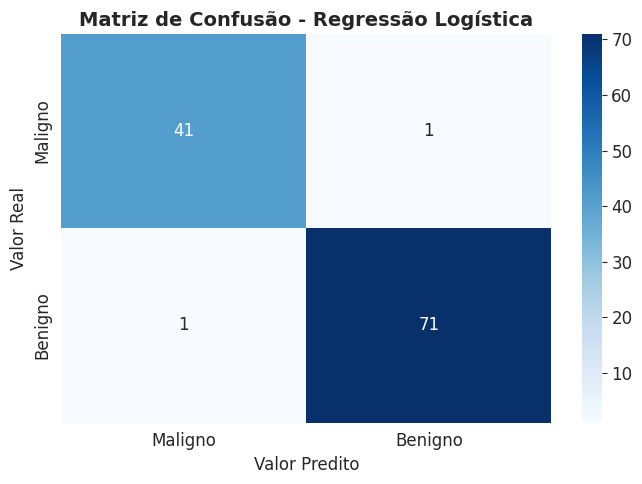

In [41]:
# Modelo 1: Regressão Logística
# Escolhemos este modelo como baseline por ser simples e rápido
modelo_lr = LogisticRegression(max_iter=10000, random_state=42)
modelo_lr.fit(X_treino_scaled, y_treino)

# Predições
y_pred_lr = modelo_lr.predict(X_teste_scaled)
y_prob_lr = modelo_lr.predict_proba(X_teste_scaled)[:, 1]

# Avaliação
print("REGRESSÃO LOGÍSTICA - Classification Report")
print("=" * 50)
exibir_classification_report(y_teste, y_pred_lr, ['Maligno', 'Benigno'])

# Matriz de confusão
plotar_matriz_confusao(y_teste, y_pred_lr, ['Maligno', 'Benigno'],
                       titulo='Matriz de Confusão - Regressão Logística',
                       salvar_em=os.path.join(DIR_RESULTADOS, 'cm_mc_regressao_logistica.png'))

### Análise dos resultados – Regressão Logística

A partir do classification report e da matriz de confusão, é possível analisar com mais detalhe o desempenho do modelo.

Observando a matriz de confusão, percebe-se que o modelo acertou a maior parte das classificações. Foram identificados corretamente 41 casos malignos e 71 casos benignos.

No entanto, ocorreram dois erros: um caso maligno foi classificado como benigno, e um caso benigno foi classificado como maligno.

Esse tipo de análise é importante porque nem todos os erros têm o mesmo impacto. No contexto da saúde, um erro onde um tumor maligno é classificado como benigno (falso negativo) pode ser mais crítico, pois pode atrasar um diagnóstico importante.

Já um falso positivo (classificar benigno como maligno) também é um problema, mas nesse caso o impacto costuma ser diferente, podendo levar a exames adicionais.

---

Analisando as métricas, o modelo apresentou valores altos de precisão, recall e f1-score para ambas as classes, todos próximos de 0.98 e 0.99. Isso indica que o modelo tem um desempenho consistente tanto na identificação de casos malignos quanto benignos.

A acurácia geral de aproximadamente 98% também reforça que o modelo teve um bom desempenho. No entanto, é importante não avaliar apenas a acurácia, principalmente em problemas médicos, onde o tipo de erro pode ser mais relevante do que a quantidade total de acertos.

---

De forma geral, os resultados mostram que a Regressão Logística foi capaz de aprender padrões relevantes nos dados, apresentando um bom desempenho mesmo sendo um modelo relativamente simples.

---

### Questionamentos sobre os resultados

Apesar dos bons resultados, alguns questionamentos podem ser levantados.

Um dos principais pontos é entender melhor os erros cometidos pelo modelo. O que levou à classificação incorreta desses casos? Existe alguma característica específica nesses dados que dificultou a decisão do modelo?

Também é importante questionar se o modelo manteria esse desempenho com novos dados, fora desse conjunto utilizado. Ou seja, será que ele realmente generaliza bem ou pode sofrer queda de desempenho em um cenário real?

Outro ponto relevante é avaliar se a acurácia alta pode estar mascarando algum problema, como por exemplo, dificuldade em identificar corretamente uma das classes em situações específicas.

Além disso, surge a dúvida se modelos mais complexos poderiam reduzir ainda mais esses erros, ou se a Regressão Logística já é suficiente para esse problema.

Por fim, considerando o contexto médico, é importante refletir se o modelo está adequado para uso como apoio à decisão, ou se ainda seriam necessários ajustes e validações adicionais.

---

Essas reflexões ajudam a entender que, mesmo com bons resultados numéricos, é essencial analisar o modelo de forma crítica antes de considerar sua aplicação prática.

### 4.2 Modelo 2: KNN (K-Nearest Neighbors)

Para o KNN, precisamos definir o número de vizinhos (K). Vamos testar diferentes valores para encontrar o melhor.

  → Gráfico salvo em: ../resultados/cm_melhor_k.png


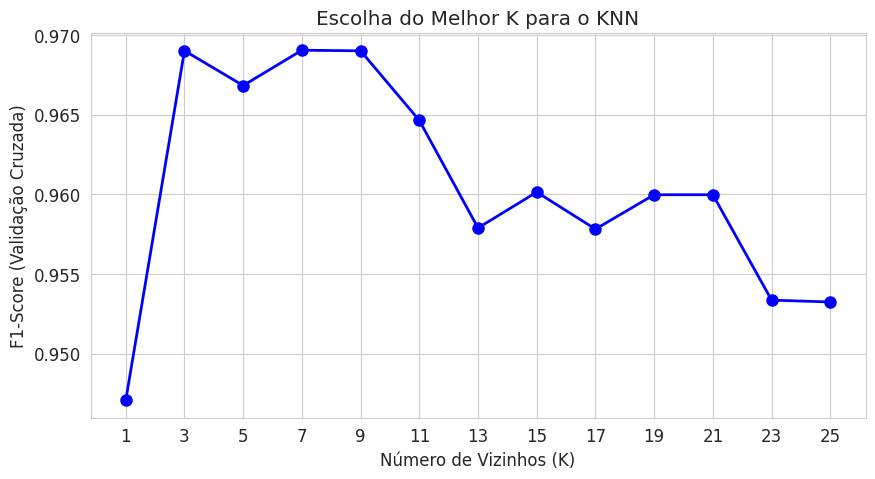

Melhor valor de K: 7 (F1-Score: 0.9691)


In [42]:
# Encontrar o melhor valor de K usando validação cruzada
# Testamos valores ímpares de 1 a 25 para evitar empates na votação
valores_k = range(1, 26, 2)
scores_k = []

for k in valores_k:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_temp, X_treino_scaled, y_treino, cv=5, scoring='f1_weighted')
    scores_k.append(scores.mean())

# Plotar resultado
plt.figure(figsize=(10, 5))
plt.plot(list(valores_k), scores_k, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de Vizinhos (K)')
plt.ylabel('F1-Score (Validação Cruzada)')
plt.title('Escolha do Melhor K para o KNN')
plt.xticks(list(valores_k))
plt.grid(True)
plt.savefig(os.path.join(DIR_RESULTADOS, 'cm_melhor_k.png'), dpi=150, bbox_inches='tight')
print(f"  → Gráfico salvo em: {os.path.join(DIR_RESULTADOS, 'cm_melhor_k.png')}")
plt.show()

melhor_k = list(valores_k)[np.argmax(scores_k)]
print(f"Melhor valor de K: {melhor_k} (F1-Score: {max(scores_k):.4f})")

KNN (K=7) - Classification Report
              precision    recall  f1-score   support

     Maligno       1.00      0.93      0.96        42
     Benigno       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

  → Gráfico salvo em: ../resultados/cm_mc_knn.png


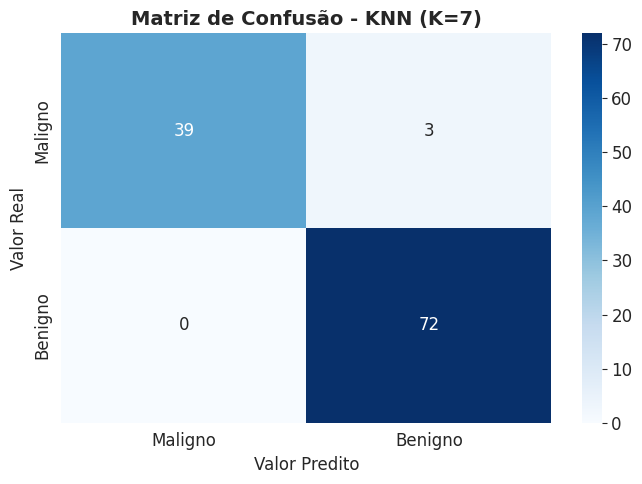

In [43]:
# Modelo 2: KNN com o melhor K encontrado
modelo_knn = KNeighborsClassifier(n_neighbors=melhor_k)
modelo_knn.fit(X_treino_scaled, y_treino)

# Predições
y_pred_knn = modelo_knn.predict(X_teste_scaled)
y_prob_knn = modelo_knn.predict_proba(X_teste_scaled)[:, 1]

# Avaliação
print(f"KNN (K={melhor_k}) - Classification Report")
print("=" * 50)
exibir_classification_report(y_teste, y_pred_knn, ['Maligno', 'Benigno'])

# Matriz de confusão
plotar_matriz_confusao(y_teste, y_pred_knn, ['Maligno', 'Benigno'],
                       titulo=f'Matriz de Confusão - KNN (K={melhor_k})',
                       salvar_em=os.path.join(DIR_RESULTADOS, 'cm_mc_knn.png'))

### 4.2 Modelo 2: KNN (K-Nearest Neighbors)

O segundo modelo utilizado foi o KNN (K-Nearest Neighbors). Diferente da Regressão Logística, esse algoritmo não cria um modelo matemático explícito, mas faz previsões com base nos dados mais próximos de cada amostra.

A ideia do KNN é simples: para classificar um novo dado, o algoritmo analisa os K vizinhos mais próximos e define a classe com base na maioria deles.

---

### Escolha do melhor valor de K

Um ponto importante no KNN é definir o valor de K (número de vizinhos). Valores muito baixos podem deixar o modelo sensível a ruídos, enquanto valores muito altos podem tornar o modelo mais generalista e perder detalhes importantes.

Para encontrar o melhor valor, foram testados diferentes valores de K (de 1 a 25, apenas ímpares para evitar empates), utilizando validação cruzada.

A partir do gráfico gerado, foi possível observar que o melhor desempenho ocorreu com K = 7, apresentando o maior valor de desempenho médio entre os testes realizados.

---

### Treinamento e avaliação do modelo

Após definir o melhor valor de K, o modelo foi treinado utilizando os dados de treino e posteriormente avaliado com o conjunto de teste.

Analisando a matriz de confusão, observa-se que:

- 39 casos malignos foram classificados corretamente
- 72 casos benignos foram classificados corretamente
- 3 casos malignos foram classificados como benignos
- Nenhum caso benigno foi classificado como maligno

---

### Análise dos resultados

O modelo apresentou uma acurácia de aproximadamente 97%, indicando um bom desempenho geral.

No entanto, ao analisar os erros, percebe-se que ocorreram 3 falsos negativos (casos malignos classificados como benignos). Esse tipo de erro é especialmente crítico na área da saúde, pois pode atrasar o diagnóstico de um paciente.

Por outro lado, o modelo não apresentou falsos positivos, ou seja, nenhum caso benigno foi classificado como maligno.

Comparando com a Regressão Logística, o KNN teve um desempenho ligeiramente inferior, principalmente por cometer mais erros na classe maligna.

---

### Questionamentos sobre o uso do KNN

Durante essa etapa, alguns pontos importantes podem ser levantados.

Um dos principais questionamentos é sobre a escolha do valor de K. Apesar de K=7 ter apresentado melhor resultado na validação cruzada, será que esse valor continua sendo o ideal para novos dados?

Outro ponto relevante é a sensibilidade do KNN à escala dos dados. Caso o escalonamento não tivesse sido aplicado corretamente, o desempenho do modelo poderia ser significativamente pior.

Também é importante considerar o custo computacional. Diferente de outros modelos, o KNN precisa calcular a distância para todas as amostras no momento da previsão, o que pode se tornar um problema em bases maiores.

Além disso, surge a dúvida sobre a robustez do modelo. Como o KNN depende diretamente dos dados, ele pode ser mais sensível a ruídos e outliers.

Outro questionamento importante é em relação aos erros cometidos. Por que o modelo errou justamente alguns casos malignos? Existe algum padrão nesses erros?

Por fim, considerando o contexto médico, é importante avaliar se esse tipo de modelo é adequado para uso prático, já que sua interpretação não é tão direta quanto modelos como a Regressão Logística ou Árvores de Decisão.

---

Esses pontos mostram que, apesar de apresentar bons resultados, o KNN também possui limitações que precisam ser consideradas na análise final.

### 4.3 Modelo 3: Árvore de Decisão

A Árvore de Decisão é um modelo que cria regras de decisão hierárquicas. Uma vantagem é que não precisa de escalonamento dos dados, mas vamos usar os dados escalonados para manter a consistência na comparação.

ÁRVORE DE DECISÃO - Classification Report
              precision    recall  f1-score   support

     Maligno       0.89      0.93      0.91        42
     Benigno       0.96      0.93      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114

  → Gráfico salvo em: ../resultados/cm_mc_arvore_decisao.png


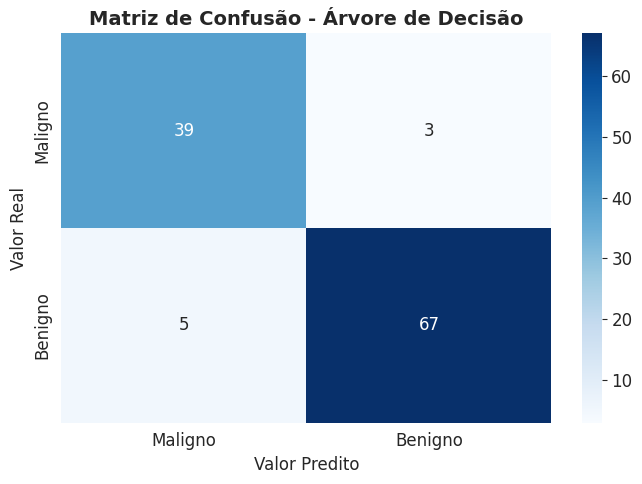

In [44]:
# Modelo 3: Árvore de Decisão
# Limitamos a profundidade para evitar overfitting
modelo_arvore = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_arvore.fit(X_treino_scaled, y_treino)

# Predições
y_pred_arvore = modelo_arvore.predict(X_teste_scaled)
y_prob_arvore = modelo_arvore.predict_proba(X_teste_scaled)[:, 1]

# Avaliação
print("ÁRVORE DE DECISÃO - Classification Report")
print("=" * 50)
exibir_classification_report(y_teste, y_pred_arvore, ['Maligno', 'Benigno'])

# Matriz de confusão
plotar_matriz_confusao(y_teste, y_pred_arvore, ['Maligno', 'Benigno'],
                       titulo='Matriz de Confusão - Árvore de Decisão',
                       salvar_em=os.path.join(DIR_RESULTADOS, 'cm_mc_arvore_decisao.png'))

### 4.3 Modelo 3: Árvore de Decisão

O terceiro modelo utilizado foi a Árvore de Decisão. Esse tipo de algoritmo funciona criando regras de decisão no formato “se-então”, dividindo os dados com base nas características mais relevantes até chegar a uma classificação final.

Uma das principais vantagens desse modelo é a interpretabilidade, já que é possível entender quais decisões estão sendo tomadas ao longo do processo. Além disso, diferentemente de modelos como KNN e Regressão Logística, a Árvore de Decisão não é sensível à escala dos dados. Mesmo assim, foi mantido o uso dos dados escalonados para garantir consistência na comparação entre os modelos.

Para evitar overfitting, foi definido um limite de profundidade (`max_depth=5`). Isso impede que a árvore cresça demais e acabe se ajustando excessivamente aos dados de treino.

---

### Treinamento e avaliação do modelo

Após o treinamento com os dados de treino, o modelo foi avaliado utilizando o conjunto de teste.

Analisando a matriz de confusão, observa-se que:

- 39 casos malignos foram classificados corretamente
- 67 casos benignos foram classificados corretamente
- 3 casos malignos foram classificados como benignos (falsos negativos)
- 5 casos benignos foram classificados como malignos (falsos positivos)

---

### Análise dos resultados

O modelo apresentou uma acurácia de aproximadamente 93%, inferior aos modelos anteriores.

Apesar disso, ele ainda conseguiu identificar corretamente a maioria dos casos. No entanto, o número de erros foi maior, tanto em falsos positivos quanto em falsos negativos.

Comparando com os outros modelos:

- A Regressão Logística apresentou melhor desempenho geral
- O KNN apresentou melhor controle de falsos positivos
- A Árvore de Decisão apresentou mais erros no geral

Um ponto importante é que a Árvore de Decisão tende a ser mais instável, podendo variar bastante dependendo dos dados utilizados.

---

Outro ponto relevante é a presença de falsos negativos (casos malignos classificados como benignos), que são críticos em aplicações na área da saúde. Além disso, também houve falsos positivos, o que pode gerar exames desnecessários.

---

### Questionamentos sobre o uso da Árvore de Decisão

Durante essa etapa, alguns pontos importantes podem ser levantados.

Um dos principais questionamentos é sobre a escolha do parâmetro `max_depth`. Será que o valor 5 foi o mais adequado? Um valor maior poderia melhorar o desempenho ou levar a overfitting?

Outro ponto relevante é a variabilidade do modelo. Como árvores de decisão podem ser instáveis, pequenas mudanças nos dados podem gerar estruturas diferentes. Isso levanta a dúvida sobre a robustez do modelo.

Também é importante questionar se a Árvore de Decisão está conseguindo capturar bem os padrões dos dados ou se está simplificando demais o problema devido à limitação de profundidade.

Além disso, surge a reflexão sobre a necessidade de utilizar modelos mais robustos baseados em árvores, como Random Forest ou Gradient Boosting, que costumam apresentar melhor desempenho.

Outro ponto importante é a comparação com os modelos anteriores. Mesmo sendo mais interpretável, será que vale a pena utilizar um modelo com desempenho inferior?

Por fim, considerando o contexto médico, é necessário avaliar se o nível de erro apresentado pelo modelo é aceitável para uso como apoio à decisão.

---

Esses questionamentos mostram que, apesar de ser um modelo simples e interpretável, a Árvore de Decisão pode não ser a melhor escolha isoladamente para esse problema, sendo importante considerar alternativas mais robustas.

---
## 5. Avaliação Comparativa dos Modelos

Agora vamos comparar os três modelos lado a lado para entender qual teve o melhor desempenho. 

### 5.1 Tabela Comparativa de Métricas

Depois de treinar e avaliar os três modelos separadamente, foi feita uma comparação geral entre eles. Essa etapa é importante porque permite observar lado a lado o desempenho da Regressão Logística, do KNN e da Árvore de Decisão no mesmo conjunto de teste.

Foram comparadas métricas gerais, como acurácia, precisão ponderada, recall ponderado e F1-Score ponderado. Essas métricas ajudam a ter uma visão geral do comportamento de cada modelo, considerando o desempenho nas duas classes: maligno e benigno.

No entanto, como o problema está relacionado ao diagnóstico de câncer de mama, apenas olhar para as métricas gerais pode não ser suficiente. Nesse contexto, um dos erros mais críticos é o falso negativo, que ocorre quando um tumor maligno é classificado como benigno.

Por esse motivo, além das métricas gerais, também foi incluído o recall específico da classe Maligno e a quantidade de falsos negativos para essa classe. Essa análise é importante porque o recall maligno mostra, entre os casos realmente malignos, quantos o modelo conseguiu identificar corretamente.

Dessa forma, a comparação fica mais alinhada ao objetivo do projeto, que é avaliar qual modelo pode apoiar melhor uma triagem inicial, reduzindo principalmente o risco de deixar passar casos malignos.


In [45]:
# Calcular métricas para cada modelo
metricas_lr = avaliar_modelo_cancer_mama(
    y_teste, 
    y_pred_lr, 
    'Regressão Logística'
)

metricas_knn = avaliar_modelo_cancer_mama(
    y_teste, 
    y_pred_knn, 
    f'KNN (K={melhor_k})'
)

metricas_arvore = avaliar_modelo_cancer_mama(
    y_teste, 
    y_pred_arvore, 
    'Árvore de Decisão'
)

# Tabela comparativa
lista_metricas = [metricas_lr, metricas_knn, metricas_arvore]
df_comparacao, df_formatado = comparar_modelos(lista_metricas)

print("COMPARAÇÃO DOS MODELOS")
print("=" * 60)
print(df_comparacao.to_string())
print()

# Identificar o melhor modelo pelo recall da classe Maligno
melhor_recall = df_comparacao['Recall Maligno'].idxmax()

print(f"→ Melhor modelo considerando Recall da classe Maligno: {melhor_recall}")
print(f"  Recall Maligno = {df_comparacao.loc[melhor_recall, 'Recall Maligno']:.4f}")
print(f"  Falsos Negativos Maligno = {df_comparacao.loc[melhor_recall, 'Falsos Negativos Maligno']:.0f}")

# Exibir tabela formatada
df_formatado

COMPARAÇÃO DOS MODELOS
                     Acurácia  Precisão Weighted  Recall Weighted  F1-Score Weighted  Recall Maligno  F1-Score Maligno  Falsos Negativos Maligno
Modelo                                                                                                                                          
Regressão Logística  0.982456           0.982456         0.982456           0.982456        0.976190          0.976190                         1
KNN (K=7)            0.973684           0.974737         0.973684           0.973465        0.928571          0.962963                         3
Árvore de Decisão    0.929825           0.931066         0.929825           0.930146        0.928571          0.906977                         3

→ Melhor modelo considerando Recall da classe Maligno: Regressão Logística
  Recall Maligno = 0.9762
  Falsos Negativos Maligno = 1


,Acurácia,Precisão Weighted,Recall Weighted,F1-Score Weighted,Recall Maligno,F1-Score Maligno,Falsos Negativos Maligno
Modelo,,,,,,,
Regressão Logística,0.9825,0.9825,0.9825,0.9825,0.9762,0.9762,1.0000
KNN (K=7),0.9737,0.9747,0.9737,0.9735,0.9286,0.9630,3.0000
Árvore de Decisão,0.9298,0.9311,0.9298,0.9301,0.9286,0.9070,3.0000


### Análise da comparação dos modelos

Analisando os resultados da tabela, a Regressão Logística apresentou o melhor desempenho geral entre os três modelos avaliados. Ela teve os maiores valores de acurácia, precisão ponderada, recall ponderado e F1-Score ponderado, todos próximos de 0.9825.

Além das métricas gerais, também foi analisado o desempenho específico para a classe Maligno. Essa análise é importante porque, no contexto de diagnóstico de câncer de mama, o erro mais crítico é classificar um tumor maligno como benigno, ou seja, gerar um falso negativo.

Nesse ponto, a Regressão Logística também apresentou o melhor resultado, com recall maligno de aproximadamente 0.9762 e apenas 1 falso negativo. Isso significa que, entre os casos realmente malignos, esse modelo conseguiu identificar corretamente a maior parte deles.

O KNN também teve um bom desempenho geral, com métricas próximas de 0.97. Porém, quando olhamos especificamente para a classe Maligno, ele ficou abaixo da Regressão Logística, apresentando recall maligno de aproximadamente 0.9286 e 3 falsos negativos.

A Árvore de Decisão teve o menor desempenho geral entre os três modelos. Apesar de ser um modelo mais fácil de interpretar, suas métricas foram menores e ela também apresentou 3 falsos negativos para a classe Maligno.

Com base nesses resultados, a Regressão Logística foi o modelo mais adequado neste experimento, pois apresentou o melhor equilíbrio entre desempenho geral, recall da classe Maligno e menor quantidade de falsos negativos.

---

### Questionamentos sobre a comparação dos modelos

Apesar da Regressão Logística ter apresentado o melhor desempenho, alguns pontos ainda precisam ser considerados.

Um primeiro questionamento é se esse resultado seria mantido com uma base de dados maior ou com dados coletados em outro hospital. O modelo pode ter funcionado bem neste dataset, mas isso não garante automaticamente o mesmo desempenho em um cenário real.

Outro ponto importante é que a escolha do melhor modelo considerou principalmente o recall da classe Maligno e a quantidade de falsos negativos. Essa decisão faz sentido no contexto médico, pois deixar passar um caso maligno pode atrasar uma investigação mais detalhada. Mesmo assim, também é importante observar outras métricas, já que falsos positivos podem gerar preocupação no paciente e necessidade de exames adicionais.

Também vale questionar se a Regressão Logística teve melhor desempenho porque o dataset favorece modelos mais lineares. Em outros conjuntos de dados, modelos mais complexos poderiam apresentar resultados diferentes.

Além disso, apesar da diferença entre Regressão Logística e KNN não ser tão grande nas métricas gerais, a diferença fica mais relevante quando observamos os falsos negativos da classe Maligno. Nesse caso, a Regressão Logística se destaca por apresentar apenas 1 falso negativo, enquanto os outros modelos apresentaram 3.

Por fim, mesmo com bons resultados, nenhum dos modelos deve ser utilizado como substituto do diagnóstico médico. O uso mais adequado seria como ferramenta de apoio à triagem, ajudando profissionais de saúde a priorizar casos que precisam de mais atenção.

---

De forma geral, a tabela comparativa mostrou que a Regressão Logística foi o modelo com melhor desempenho neste experimento. Ela apresentou bons resultados nas métricas gerais e também foi o modelo que melhor lidou com a classe Maligno, reduzindo a quantidade de falsos negativos. Ainda assim, para uso prático, seria necessário validar o modelo com mais dados e sempre manter o médico como responsável pela decisão final.

### 5.2 Validação Cruzada

Para complementar a avaliação feita no conjunto de teste, foi aplicada a validação cruzada com 5 folds. A ideia dessa etapa é verificar se o desempenho dos modelos se mantém estável quando os dados são divididos de formas diferentes.

Na avaliação anterior, os modelos foram comparados usando uma separação fixa entre treino e teste. Esse processo é importante, mas pode depender da forma como os dados foram divididos. Com a validação cruzada, o modelo é treinado e avaliado várias vezes, utilizando diferentes partes da base em cada rodada.

Neste projeto, foi utilizada a validação cruzada estratificada, por meio do `StratifiedKFold`. Essa escolha ajuda a manter a proporção entre casos malignos e benignos em cada divisão, o que é importante em problemas de classificação médica.

Também foi utilizado um `Pipeline`, combinando o `StandardScaler` com cada modelo. Isso garante que o escalonamento seja aplicado corretamente dentro de cada fold, evitando vazamento de dados durante a validação.

Como o foco principal do problema é reduzir falsos negativos em casos malignos, a métrica utilizada nesta etapa foi o recall da classe Maligno. Dessa forma, a validação cruzada avalia a capacidade dos modelos de identificar corretamente os casos realmente malignos em diferentes divisões da base.

VALIDAÇÃO CRUZADA (5-Fold)
Regressão Logística      : Recall Maligno = 0.9436 (+/- 0.0525)
KNN (K=7)                : Recall Maligno = 0.9153 (+/- 0.0671)
Árvore de Decisão        : Recall Maligno = 0.8823 (+/- 0.0690)
  → Gráfico salvo em: ../resultados/cm_validacao_cruzada.png


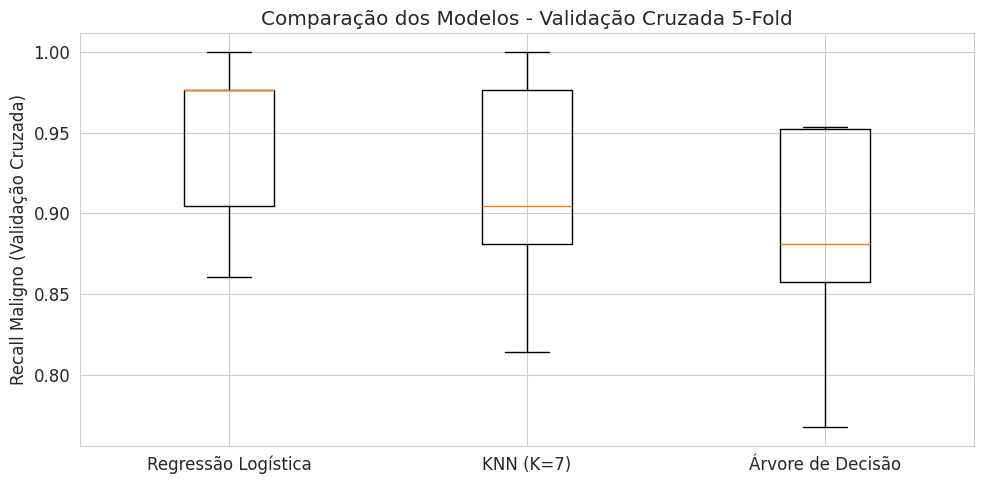

In [51]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer

# Validação cruzada com 5 folds estratificados
# O objetivo aqui é avaliar a estabilidade dos modelos considerando o recall da classe Maligno
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Scorer específico para a classe Maligno
# Considerando que: 0 = Maligno e 1 = Benigno
recall_maligno_scorer = make_scorer(
    recall_score,
    pos_label=0
)

modelos_cv = {
    'Regressão Logística': LogisticRegression(max_iter=10000, random_state=42),
    f'KNN (K={melhor_k})': KNeighborsClassifier(n_neighbors=melhor_k),
    'Árvore de Decisão': DecisionTreeClassifier(max_depth=5, random_state=42)
}

print("VALIDAÇÃO CRUZADA (5-Fold)")
print("=" * 60)

resultados_cv = {}

for nome, modelo in modelos_cv.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('modelo', modelo)
    ])

    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=recall_maligno_scorer
    )

    resultados_cv[nome] = scores

    print(f"{nome:25}: Recall Maligno = {scores.mean():.4f} (+/- {scores.std():.4f})")

# Visualizar em boxplot
fig, ax = plt.subplots(figsize=(10, 5))

ax.boxplot(
    resultados_cv.values(),
    labels=resultados_cv.keys()
)

ax.set_ylabel('Recall Maligno (Validação Cruzada)')
ax.set_title('Comparação dos Modelos - Validação Cruzada 5-Fold')

plt.tight_layout()

fig.savefig(
    os.path.join(DIR_RESULTADOS, 'cm_validacao_cruzada.png'),
    dpi=150,
    bbox_inches='tight'
)

print(f"  → Gráfico salvo em: {os.path.join(DIR_RESULTADOS, 'cm_validacao_cruzada.png')}")

plt.show()

### Análise da validação cruzada

Analisando os resultados da validação cruzada, a Regressão Logística apresentou o melhor desempenho médio considerando o recall da classe Maligno, com valor aproximado de 0.9436. Isso indica que, ao longo das diferentes divisões da base, esse modelo conseguiu identificar uma maior proporção dos casos malignos.

O KNN apresentou um desempenho um pouco menor, com recall maligno médio próximo de 0.9153. Apesar de ainda ser um resultado razoável, ele ficou abaixo da Regressão Logística e apresentou uma variação maior entre os folds.

A Árvore de Decisão teve o menor desempenho médio, com recall maligno em torno de 0.8823. Além disso, pelo gráfico de boxplot, é possível perceber uma maior variação nos resultados, indicando que o desempenho desse modelo depende mais da divisão dos dados.

O boxplot ajuda a visualizar não apenas a média, mas também a estabilidade dos modelos. Nesse caso, a Regressão Logística apresentou um desempenho mais alto e relativamente estável, enquanto o KNN e a Árvore de Decisão tiveram maior variação.

Um ponto importante é que os valores da validação cruzada ficaram menores do que os resultados obtidos no teste fixo anterior. Isso é esperado, pois a validação cruzada avalia os modelos em diferentes divisões da base, tornando a análise mais exigente e mais realista.

---

### Questionamentos sobre a validação cruzada

Mesmo com a validação cruzada, alguns pontos ainda podem ser questionados.

Um primeiro ponto é se 5 folds são suficientes para avaliar bem os modelos. Em alguns casos, utilizar mais folds poderia gerar uma estimativa mais estável, mas também aumentaria o custo computacional.

Outro ponto importante é que a validação cruzada foi feita sobre o dataset disponível, que ainda é uma base limitada. Mesmo que o modelo tenha bom desempenho nessa validação, isso não garante automaticamente que ele terá o mesmo comportamento em dados de outros hospitais ou populações diferentes.

Também é válido questionar a variação dos resultados entre os folds. Quando um modelo apresenta muita variação, isso pode indicar que ele é mais sensível à divisão dos dados e talvez menos estável em cenários reais.

Além disso, como o foco foi o recall da classe Maligno, é importante lembrar que essa métrica não mostra tudo sozinha. Um modelo com alto recall maligno pode reduzir falsos negativos, mas também pode aumentar falsos positivos, o que exigiria uma análise complementar.

Por fim, a validação cruzada reforça que a Regressão Logística foi o modelo mais consistente neste experimento, mas ainda seria necessário testar o modelo em bases externas antes de pensar em qualquer aplicação prática.

---

De forma geral, a validação cruzada confirmou a tendência observada na comparação anterior: a Regressão Logística apresentou o melhor equilíbrio para este problema, principalmente considerando a identificação dos casos malignos. Mesmo assim, os resultados devem ser interpretados como apoio à análise, e não como garantia de uso clínico sem validações adicionais.

### 5.3 Curvas ROC

A curva ROC (Receiver Operating Characteristic) nos permite visualizar o trade-off entre a taxa de verdadeiros positivos e a taxa de falsos positivos. Quanto mais próxima a curva do canto superior esquerdo, melhor o modelo. A área sob a curva (AUC) resume esse desempenho em um único número.

  → Gráfico salvo em: ../resultados/cm_curvas_roc.png


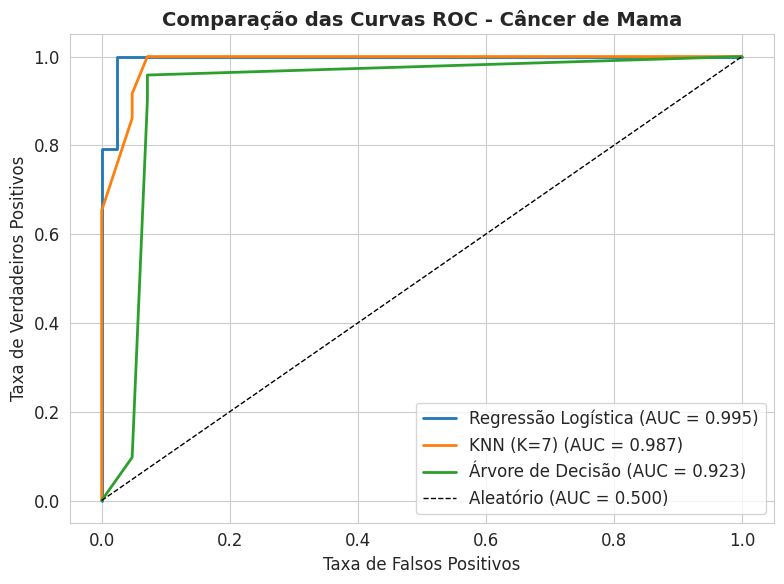

In [ ]:
# PARAMOS AQUI
# Plotar curvas ROC comparativas
resultados_roc = {
    'Regressão Logística': y_prob_lr,
    f'KNN (K={melhor_k})': y_prob_knn,
    'Árvore de Decisão': y_prob_arvore
}

plotar_curvas_roc_comparativas(
    y_teste, resultados_roc,
    titulo='Comparação das Curvas ROC - Câncer de Mama',
    salvar_em=os.path.join(DIR_RESULTADOS, 'cm_curvas_roc.png')
)

---

## 6. Interpretação dos Resultados

Além de saber que um modelo funciona bem, é importante entender **por que** ele faz determinadas predições. Isso é especialmente crítico na área médica, onde o modelo precisa ser explicável para que os médicos confiem nas suas sugestões.

### 6.1 Feature Importance (Árvore de Decisão)

A Árvore de Decisão nos dá uma medida direta de importância de cada feature: quanto cada uma contribui para a separação das classes.

  → Gráfico salvo em: ../resultados/cm_feature_importance.png


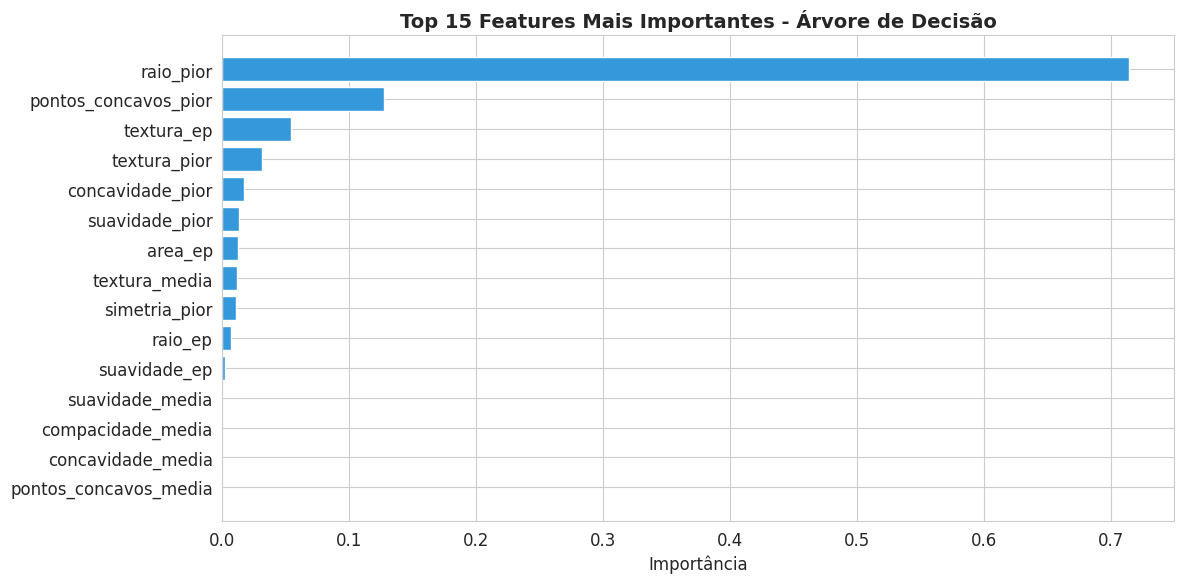

Top 10 Features mais importantes:
  1. raio_pior                      - Importância: 0.7143
  2. pontos_concavos_pior           - Importância: 0.1275
  3. textura_ep                     - Importância: 0.0539
  4. textura_pior                   - Importância: 0.0315
  5. concavidade_pior               - Importância: 0.0167
  6. suavidade_pior                 - Importância: 0.0130
  7. area_ep                        - Importância: 0.0124
  8. textura_media                  - Importância: 0.0115
  9. simetria_pior                  - Importância: 0.0110
  10. raio_ep                        - Importância: 0.0064


In [48]:
# Feature Importance da Árvore de Decisão
importancias = modelo_arvore.feature_importances_
indices = np.argsort(importancias)[::-1]

# Plotar as 15 features mais importantes
top_n = 15
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(top_n), importancias[indices[:top_n]][::-1], color='#3498db')
ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_names[i] for i in indices[:top_n]][::-1])
ax.set_xlabel('Importância')
ax.set_title('Top 15 Features Mais Importantes - Árvore de Decisão', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(DIR_RESULTADOS, 'cm_feature_importance.png'), dpi=150, bbox_inches='tight')
print(f"  → Gráfico salvo em: {os.path.join(DIR_RESULTADOS, 'cm_feature_importance.png')}")
plt.show()

# Exibir valores
print("Top 10 Features mais importantes:")
for i in range(10):
    print(f"  {i+1}. {feature_names[indices[i]]:30s} - Importância: {importancias[indices[i]]:.4f}")

### 6.2 SHAP Values

SHAP (SHapley Additive exPlanations) é uma técnica que nos permite entender a contribuição de cada feature para cada predição individual. Diferente da feature importance que dá uma visão global, o SHAP mostra como cada feature influencia a predição para cada amostra.

Vamos aplicar o SHAP no modelo de Árvore de Decisão para entender suas decisões.

SHAP Summary Plot - Árvore de Decisão
Cada ponto é uma amostra. Cor vermelha = valor alto da feature, azul = valor baixo.
Posição à direita = contribui para classificar como benigno.

  → Gráfico salvo em: ../resultados/cm_shap_summary.png


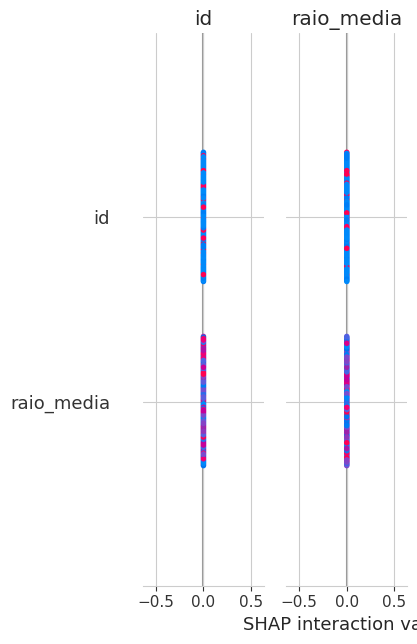

In [49]:
# SHAP - Interpretabilidade do modelo de Árvore de Decisão
# Usamos TreeExplainer pois é otimizado para modelos baseados em árvores

explainer = shap.TreeExplainer(modelo_arvore)
shap_values = explainer.shap_values(X_teste_scaled)

# Summary plot - mostra a importância e o efeito de cada feature
print("SHAP Summary Plot - Árvore de Decisão")
print("Cada ponto é uma amostra. Cor vermelha = valor alto da feature, azul = valor baixo.")
print("Posição à direita = contribui para classificar como benigno.")
print()

# Converter para numpy array (necessário para indexação do SHAP)
feature_names_array = np.array(feature_names)

# Para classificação binária, pegamos os shap_values da classe 1 (benigno)
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

shap.summary_plot(
    shap_values_plot,
    X_teste_scaled,
    feature_names=feature_names_array,
    show=False
)
plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTADOS, 'cm_shap_summary.png'), dpi=150, bbox_inches='tight')
print(f"  → Gráfico salvo em: {os.path.join(DIR_RESULTADOS, 'cm_shap_summary.png')}")
plt.show()

  → Gráfico salvo em: ../resultados/cm_shap_bar.png


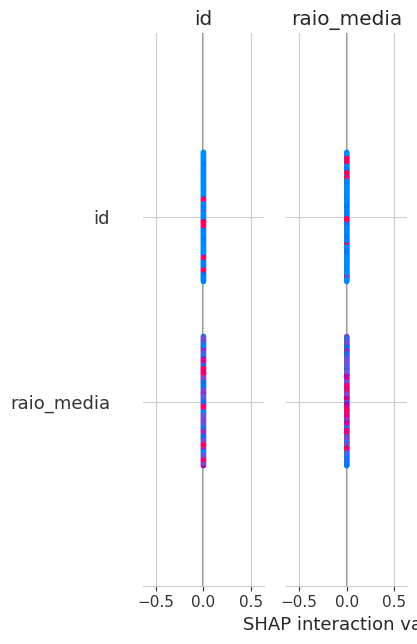

In [50]:
# SHAP Bar Plot - visão resumida da importância média de cada feature
shap.summary_plot(
    shap_values_plot,
    X_teste_scaled,
    feature_names=feature_names_array,
    plot_type='bar',
    show=False
)
plt.tight_layout()
plt.savefig(os.path.join(DIR_RESULTADOS, 'cm_shap_bar.png'), dpi=150, bbox_inches='tight')
print(f"  → Gráfico salvo em: {os.path.join(DIR_RESULTADOS, 'cm_shap_bar.png')}")
plt.show()

**Interpretação do SHAP:** Os gráficos SHAP confirmam que features como `worst perimeter`, `worst concave points` e `mean concave points` são as mais influentes na classificação. Isso é consistente com o conhecimento médico: tumores malignos tendem a ter bordas irregulares (alto perímetro) e mais pontos côncavos (indicando forma irregular da célula).

---

## 7. Discussão Crítica

### O modelo pode ser utilizado na prática?

Os modelos apresentaram bons resultados nas métricas de avaliação, especialmente a Regressão Logística e o KNN. No entanto, é fundamental considerar os seguintes pontos:

**Pontos fortes:**
- Altas taxas de recall, o que é crucial em diagnósticos médicos (minimizar falsos negativos)
- O modelo é capaz de destacar quais características são mais relevantes para o diagnóstico
- O processamento é rápido e pode auxiliar na triagem de exames

**Limitações:**
- O dataset é relativamente pequeno (569 amostras). Em um cenário real, seria necessário treinar com muito mais dados
- Os dados são limpos e bem estruturados, o que raramente acontece em dados reais de hospitais
- O modelo trabalha apenas com features numéricas extraídas — não analisa as imagens diretamente

**O papel do médico:**
É essencial ressaltar que **o médico sempre deve ter a palavra final no diagnóstico**. O modelo de ML deve ser visto como uma **ferramenta de apoio**, não como um substituto do profissional. Ele pode:
- Auxiliar na triagem rápida de exames
- Chamar a atenção para casos que merecem análise mais cuidadosa
- Servir como "segunda opinião" automatizada

Mas a decisão final, considerando o histórico do paciente, exame clínico e outros fatores, sempre será do médico.

---

*Notebook desenvolvido como parte do Tech Challenge - Fase 1 | FIAP Pós Tech - AI for Devs*